# packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Packages

The generator function of random sequences of two angles input, present in the  "01_quantum_walk_functions.ipynb", was modified to make fixed random sequences using a seed.

In [2]:
# função para calcular o módulo quadrado da função de onda
mod = lambda a: np.sum(np.square(np.abs(a)), axis=1)

# coin
def C(theta):
    return np.array([
        [np.cos(theta), 1j*np.sin(theta)],
        [1j*np.sin(theta), np.cos(theta)]
    ])

# random list
rand_numbers = lambda seed, size: np.random.default_rng(seed=seed).integers(0,2,size)
rand = lambda theta1, theta2, list_rand_numbers: np.where(list_rand_numbers,theta1,theta2)

# theta list
def theta_list(theta0,dtheta_list):
    return [theta0 + dtheta for dtheta in dtheta_list], [theta0 - dtheta for dtheta in dtheta_list]

# DTQW with random coin
def DTQW_rand(theta1,theta2,T,list_rand_numbers):

      nr = 2*T+3 # tamanho da rede
      m = nr//2
      a = np.zeros((nr,2), dtype=complex)
      #estado inicial
      a[m, 0] = 1/np.sqrt(2)
      a[m, 1] = 1/np.sqrt(2)
      prob_T = np.zeros((nr,T+1))
      prob_T[:, 0] = mod(a)

      # random theta list
      ttr = rand(theta1,theta2,list_rand_numbers)
      # walking
      for i in range(T):      # passos
          Cr = C(ttr[i])
          r = a[m-i-1:m+i+2,0]*Cr[0,0] + a[m-i-1:m+i+2, 1]*Cr[0,1]
          l = a[m-i-1:m+i+2,0]*Cr[1,0] + a[m-i-1:m+i+2, 1]*Cr[1,1]
          a[m-i:m+i+3, 0], a[m-i-2:m+i+1, 1] = r, l

      return mod(a) # modulus of array

# DTQW with random coin - amplitude version
def DTQW_rand_amp(theta1,theta2,T,list_rand_numbers):

      nr = 2*T+3 # tamanho da rede
      m = nr//2
      a = np.zeros((nr,2), dtype=complex)
      #estado inicial
      a[m, 0] = 1/np.sqrt(2)
      a[m, 1] = 1/np.sqrt(2)
      prob_T = np.zeros((nr,T+1))
      prob_T[:, 0] = mod(a)

      # random theta list
      ttr = rand(theta1,theta2,list_rand_numbers)

      # walking
      for i in range(T):      # passos
          Cr = C(ttr[i])
          r = a[m-i-1:m+i+2,0]*Cr[0,0] + a[m-i-1:m+i+2, 1]*Cr[0,1]
          l = a[m-i-1:m+i+2,0]*Cr[1,0] + a[m-i-1:m+i+2, 1]*Cr[1,1]
          a[m-i:m+i+3, 0], a[m-i-2:m+i+1, 1] = r, l

      return a 

# IPR calculation (Definindo o IPR de acordo com Mastandrea e Chen (2023))
IPR = lambda coin_amp: (np.sum(np.square(np.abs(coin_amp)))**2)/np.sum(np.square(np.abs(coin_amp))**2)
#OBS. coin_amp: amplitude de probabilidade da partícula está em x com uma determinada moeda ( |x,+> )

# IPR time evolution
def IPR_time(theta1,theta2,T,list_rand_numbers):

      nr = 2*T+3 # tamanho da rede
      m = nr//2
      a = np.zeros((nr,2), dtype=complex)
      IPR_list = np.zeros(T+1)
      #estado inicial
      a[m, 0] = 1/np.sqrt(2)
      a[m, 1] = 1/np.sqrt(2)
      prob_T = np.zeros((nr,T+1))
      prob_T[:, 0] = mod(a)

      # random theta list
      ttr = rand(theta1,theta2,list_rand_numbers)

      # walking
      for i in range(T):      # passos
          Cr = C(ttr[i])
          r = a[m-i-1:m+i+2,0]*Cr[0,0] + a[m-i-1:m+i+2, 1]*Cr[0,1]
          l = a[m-i-1:m+i+2,0]*Cr[1,0] + a[m-i-1:m+i+2, 1]*Cr[1,1]
          a[m-i:m+i+3, 0], a[m-i-2:m+i+1, 1] = r, l
          IPR_list[i+1] = IPR(r)
      return IPR_list

# IPR at final time
def IPR_final_time(theta1,theta2,T,list_rand_numbers):

      nr = 2*T+3 # tamanho da rede
      m = nr//2
      a = np.zeros((nr,2), dtype=complex)
      IPR_list = np.zeros(T+1)
      #estado inicial
      a[m, 0] = 1/np.sqrt(2)
      a[m, 1] = 1/np.sqrt(2)
      prob_T = np.zeros((nr,T+1))
      prob_T[:, 0] = mod(a)

      # random theta list
      ttr = rand(theta1,theta2,list_rand_numbers)

      # walking
      for i in range(T):      # passos
          Cr = C(ttr[i])
          r = a[m-i-1:m+i+2,0]*Cr[0,0] + a[m-i-1:m+i+2, 1]*Cr[0,1]
          l = a[m-i-1:m+i+2,0]*Cr[1,0] + a[m-i-1:m+i+2, 1]*Cr[1,1]
          a[m-i:m+i+3, 0], a[m-i-2:m+i+1, 1] = r, l
      return IPR(r)



# Mol calculation
def Mol(Prob):
    positions = np.arange(-(len(Prob)//2), len(Prob)//2 + 1)
    return np.sum((positions**2) * Prob)

# Mol time evolution
def Mol_time(theta1,theta2,T,list_rand_numbers):

      nr = 2*T+3 # tamanho da rede
      m = nr//2
      a = np.zeros((nr,2), dtype=complex)
      Mol_list = np.zeros(T+1)
      #estado inicial
      a[m, 0] = 1/np.sqrt(2)
      a[m, 1] = 1/np.sqrt(2)
      prob_T = np.zeros((nr,T+1))
      prob_T[:, 0] = mod(a)

      # random theta list
      ttr = rand(theta1,theta2,list_rand_numbers)

      # walking
      for i in range(T):      # passos
          Cr = C(ttr[i])
          r = a[m-i-1:m+i+2,0]*Cr[0,0] + a[m-i-1:m+i+2, 1]*Cr[0,1]
          l = a[m-i-1:m+i+2,0]*Cr[1,0] + a[m-i-1:m+i+2, 1]*Cr[1,1]
          a[m-i:m+i+3, 0], a[m-i-2:m+i+1, 1] = r, l
          Mol_list[i+1] = Mol(mod(a))
      return Mol_list 

# Mol at final time
def Mol_final_time(theta1,theta2,T,list_rand_numbers):

      nr = 2*T+3 # tamanho da rede
      m = nr//2
      a = np.zeros((nr,2), dtype=complex)
      #estado inicial
      a[m, 0] = 1/np.sqrt(2)
      a[m, 1] = 1/np.sqrt(2)
      prob_T = np.zeros((nr,T+1))
      prob_T[:, 0] = mod(a)

      # random theta list
      ttr = rand(theta1,theta2,list_rand_numbers)

      # walking
      for i in range(T):      # passos
          Cr = C(ttr[i])
          r = a[m-i-1:m+i+2,0]*Cr[0,0] + a[m-i-1:m+i+2, 1]*Cr[0,1]
          l = a[m-i-1:m+i+2,0]*Cr[1,0] + a[m-i-1:m+i+2, 1]*Cr[1,1]
          a[m-i:m+i+3, 0], a[m-i-2:m+i+1, 1] = r, l
      return Mol(mod(a))

# Função para obter os dados de simulação (probabilidades finais e IPR final)
def get_simulation_data(theta1, theta2, T, list_rand_numbers):
    nr = 2*T+3 
    m = nr//2
    a = np.zeros((nr,2), dtype=complex)
    
    # Estado inicial
    a[m, 0] = 1/np.sqrt(2)
    a[m, 1] = 1/np.sqrt(2)

    # Lista de thetas aleatórios
    ttr = rand(theta1, theta2, list_rand_numbers)

    # Variável auxiliar para guardar o componente 'r' final para o cálculo do IPR
    last_r = None 

    # Walking
    for i in range(T):
        Cr = C(ttr[i])
        r = a[m-i-1:m+i+2,0]*Cr[0,0] + a[m-i-1:m+i+2, 1]*Cr[0,1]
        l = a[m-i-1:m+i+2,0]*Cr[1,0] + a[m-i-1:m+i+2, 1]*Cr[1,1]
        a[m-i:m+i+3, 0], a[m-i-2:m+i+1, 1] = r, l
        last_r = r # Guarda a referência do último r
        
    # Retorna: (Probabilidades finais, Valor do IPR calculado sobre r)
    return mod(a), IPR(last_r)

# IPR for one single random sequence

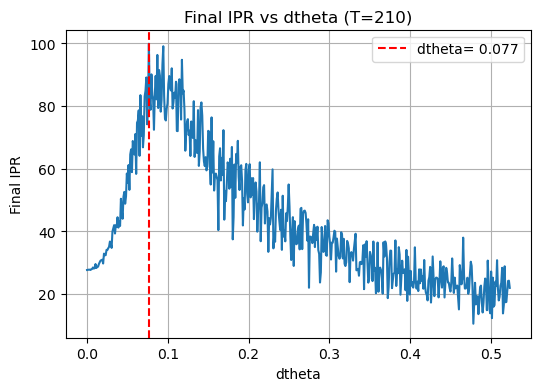

In [3]:
#list_rn = rand_numbers(seed=None, size=1000)
T = 210
theta_0 = np.pi/6
dtheta_list = np.linspace(0, theta_0, 500)
Theta_list = theta_list(np.pi/6,dtheta_list)

IPR_final = []
for th1, th2 in zip(Theta_list[0], Theta_list[1]):
    IPR_final.append(IPR_final_time(th1, th2, T, rand_numbers(seed=None, size=1000)))

plt.figure(figsize=(6,4))
plt.plot(dtheta_list, IPR_final)
plt.axvline(x=dtheta_list[np.argmax(IPR_final)], color='red', linestyle='--', label='dtheta= ' + str(np.round(dtheta_list[np.argmax(IPR_final)],3)))
plt.title('Final IPR vs dtheta'+' (T='+str(T)+')')
plt.xlabel('dtheta')
plt.ylabel('Final IPR')
plt.legend()
plt.grid(True)
plt.show()

## Coletando dados

In [4]:
# --- Parâmetros ---
data_number = 2500
T = 100
theta_0 = np.pi/6
dtheta_list = np.linspace(0, theta_0, data_number)
num_random_samples = 1000 # Tamanho da lista de números aleatórios (deve ser > T)

# Lista para armazenar o dataset completo
# Formato sugerido: Cada item será [delta_theta, valor_ipr, array_probabilidades]
dataset_treino = []

print("Iniciando coleta de dados...")

# Loop através dos valores de desordem (Delta Theta)
for dtheta in dtheta_list:
    # Definindo theta1 e theta2 baseados no dtheta atual
    th1 = theta_0 + dtheta
    th2 = theta_0 - dtheta
    
    # Gera números aleatórios novos para esta execução
    # (seed=None garante aleatoriedade a cada passo)
    current_rand_nums = rand_numbers(seed=None, size=num_random_samples)
    
    # Executa a simulação e pega os dois resultados
    prob_dist, ipr_val = get_simulation_data(th1, th2, T, current_rand_nums)
    
    # Salva no formato desejado: [Delta_Theta, IPR, Array_Probabilidades]
    # Aqui estou criando um dicionário ou lista. Para treinar máquina, lista é melhor.
    data_point = {
        'delta_theta': dtheta,
        'IPR': ipr_val,
        'probs': prob_dist
    }
    
    dataset_treino.append(data_point)

print(f"Coleta finalizada. Total de amostras: {len(dataset_treino)}")

Iniciando coleta de dados...
Coleta finalizada. Total de amostras: 2500


In [5]:
# --- 3. Criação e Formatação do DataFrame ---
df = pd.DataFrame(dataset_treino)

# Expandir a coluna 'probs' (que é um array) em várias colunas (uma para cada posição x)
# Isso cria colunas chamadas 0, 1, 2, ..., N com as probabilidades
probs_df = pd.DataFrame(df['probs'].tolist())

# Opcional: Renomear as colunas de probabilidade para algo como "prob_0", "prob_1"...
probs_df.columns = [f'prob_{i}' for i in range(probs_df.shape[1])]

# Juntar tudo: Delta Theta + IPR + Colunas de Probabilidade
df_final = pd.concat([df[['delta_theta', 'IPR']], probs_df], axis=1)

# --- 4. Salvar em CSV --

# Criando o nome do arquivo dinamicamente
nome_arquivo = f'dados_quantum_walk_T_{T}_data_{data_number}.csv'

# Salvando no caminho desejado
df_final.to_csv(f'data/{nome_arquivo}', index=False)

print(f"Arquivo salvo com sucesso: data/{nome_arquivo}")

Arquivo salvo com sucesso: data/dados_quantum_walk_T_100_data_2500.csv


In [6]:
df.head()

,delta_theta,IPR,probs
0,0.000000,16.049482,"[0.0, 2.1381347902543647e-13, 0.0, 2.283052814..."
1,0.000210,16.053533,"[0.0, 2.1211197854324304e-13, 0.0, 2.266404141..."
2,0.000419,16.044893,"[0.0, 2.1515769337564965e-13, 0.0, 2.296229888..."
3,0.000629,16.053919,"[0.0, 2.1302783488999603e-13, 0.0, 2.275342173..."
4,0.000838,16.071172,"[0.0, 2.1030516124577397e-13, 0.0, 2.248443514..."


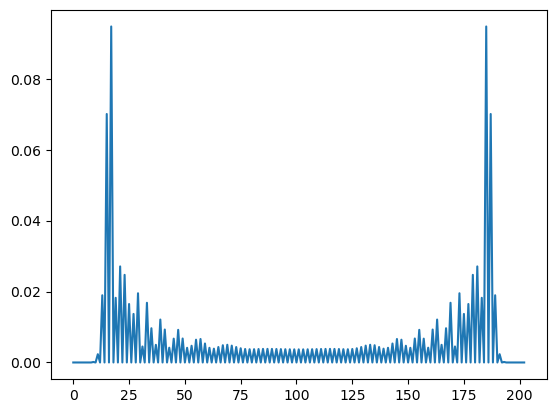

In [7]:
plt.plot(df['probs'][0])
plt.show()

## Coletando com mais amostras

In [8]:
# --- Parâmetros ---
data_number = 2500
T = 100
theta_0 = np.pi/6
dtheta_list = np.linspace(0, theta_0, data_number)
num_random_samples = 1000 # Tamanho da lista de números aleatórios (deve ser > T)
num_samples_per_dtheta = 100 # Quantas amostras queremos para cada valor de dtheta (pode ser >1 para mais robustez)

# Lista para armazenar o dataset completo
# Formato sugerido: Cada item será [delta_theta, valor_ipr, array_probabilidades]
dataset_treino2 = []

print("Iniciando coleta de dados...")

for sample in range(num_samples_per_dtheta):
    # Loop através dos valores de desordem (Delta Theta)
    for dtheta in dtheta_list:
        # Definindo theta1 e theta2 baseados no dtheta atual
        th1 = theta_0 + dtheta
        th2 = theta_0 - dtheta
        
        # Gera números aleatórios novos para esta execução
        # (seed=None garante aleatoriedade a cada passo)
        current_rand_nums = rand_numbers(seed=None, size=num_random_samples)
        
        # Executa a simulação e pega os dois resultados
        prob_dist, ipr_val = get_simulation_data(th1, th2, T, current_rand_nums)
        
        # Salva no formato desejado: [Delta_Theta, IPR, Array_Probabilidades]
        # Aqui estou criando um dicionário ou lista. Para treinar máquina, lista é melhor.
        data_point = {
            'delta_theta': dtheta,
            'IPR': ipr_val,
            'probs': prob_dist
        }
        
        dataset_treino2.append(data_point)

print(f"Coleta finalizada. Total de amostras: {len(dataset_treino)}")

Iniciando coleta de dados...
Coleta finalizada. Total de amostras: 2500


In [9]:
# --- 3. Criação e Formatação do DataFrame ---
df = pd.DataFrame(dataset_treino2)

# Expandir a coluna 'probs' (que é um array) em várias colunas (uma para cada posição x)
# Isso cria colunas chamadas 0, 1, 2, ..., N com as probabilidades
probs_df = pd.DataFrame(df['probs'].tolist())

# Opcional: Renomear as colunas de probabilidade para algo como "prob_0", "prob_1"...
probs_df.columns = [f'prob_{i}' for i in range(probs_df.shape[1])]

# Juntar tudo: Delta Theta + IPR + Colunas de Probabilidade
df_final = pd.concat([df[['delta_theta', 'IPR']], probs_df], axis=1)

# --- 4. Salvar em CSV --

# Criando o nome do arquivo dinamicamente
nome_arquivo = f'dados_quantum_walk_T_{T}_data_{data_number}_2.csv'

# Salvando no caminho desejado
df_final.to_csv(f'data/{nome_arquivo}', index=False)

print(f"Arquivo salvo com sucesso: data/{nome_arquivo}")

Arquivo salvo com sucesso: data/dados_quantum_walk_T_100_data_2500_2.csv
